##  Pandas Excercise from

url: https://github.com/techwithtim/PanadasTutorial

In [1]:
# Example Data Frame

import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Country': ['USA', 'Canada', 'UK']
}

df = pd.DataFrame(data)
print(df)

      Name  Age Country
0    Alice   25     USA
1      Bob   30  Canada
2  Charlie   35      UK


## Creating ROC & Precision-Recall Curves From Scratch

url: https://medium.com/towards-artificial-intelligence/data-science-interview-question-creating-roc-precision-recall-curves-from-scratch-b4149f12f267

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

This is one of the popular data science interview questions which requires one to create the ROC and similar curves from scratch, i.e., no data on hand.

The first step is to generate the ‘actual’ data of 1s (bads) and 0s (goods), because this will be used to calculate and compare the model accuracy via the aforementioned metrics. For this article, we will create the “actual vector” from Uniform distribution. For the subsequent and related article, we will use Binomial distribution.

In [2]:
actual = np.random.randint(0, 2, 10000)

The above code generates 10,000 random integers belonging to [0,1] which is our vector of the actual binary class. Now, of course we need another vector of probabilities for these actual classes. Normally, these probabilities are an output of a Machine learning model. However, here we will generate them randomly making some useful assumptions. Let’s assume the underlying model is a ‘logistic regression model’, therefore, the link function is logistic or logit.

The figure below describes the standard logistic function. For a logistic regression model, the expression -k(x-x_0) is replaced by a ‘score’. The ‘score’ is a weighted sum of model features and model parameters.

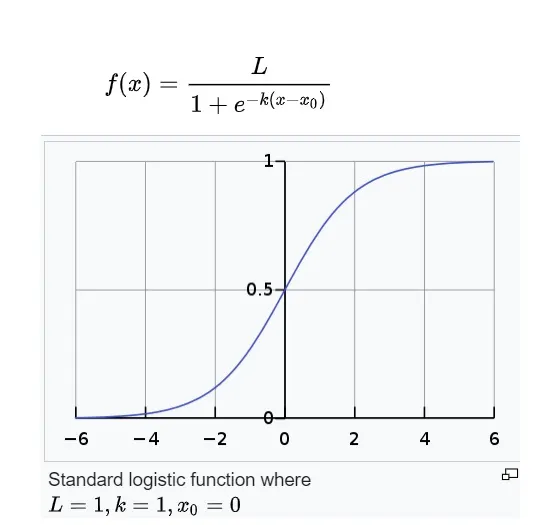

Thus, when the ‘score’ = 0, the logistic function must pass through 0.5 on the Y-axis. This is because logit(p) = log-odds(p) = log(p/(1-p)) = 0 => p = 1-p => p =0.5. Also notice that when the ‘score’ attains high positive or high negative values, the function asymptotically moves towards either 1 (bad) or 0 (good). Thus, the higher the absolute value of ‘score’ is, the higher the predicted probability is as well. But what are we scoring? We are scoring each data input present in our ‘actual vector’. Then, if we want to assume that our underlying logistic regression model is skilled, i.e., predictive; the model should assign comparatively higher scores to bads vs goods. Thus, bads should have more positive scores (to ensure that the predicted probability is close to 1) and goods should have more negative scores (to ensure that the predicted probability is close to 0). This is known as rank ordering by the model. In other words, there should be discrimination or separation between the scores and hence the predicted probabilities of bads vs goods. Since, we have seen that the score of 0 implies probability of good = probability of bad = 0.5; this would mean the model is unable to differentiate between good and bad. But since we do know that the data point will be actually either good or bad, therefore, a score of 0.5 is the worst possible score from the model. This gives us some intuition to move to the next step.

The scores can be randomly generated using the Standard Normal distribution with a mean of 0 and a standard deviation of 1. However, we want different predicted scores for bads and goods. We also want bad scores should be higher than the good scores. Thus, we use the standard normal distribution and shift its mean to create a separation between the goods and the bads.

(array([  11.,   46.,  226.,  668., 1212., 1298.,  952.,  487.,  136.,
          23.]),
 array([-4.59075878, -3.91075751, -3.23075623, -2.55075496, -1.87075368,
        -1.1907524 , -0.51075113,  0.16925015,  0.84925142,  1.5292527 ,
         2.20925398]),
 <BarContainer object of 10 artists>)

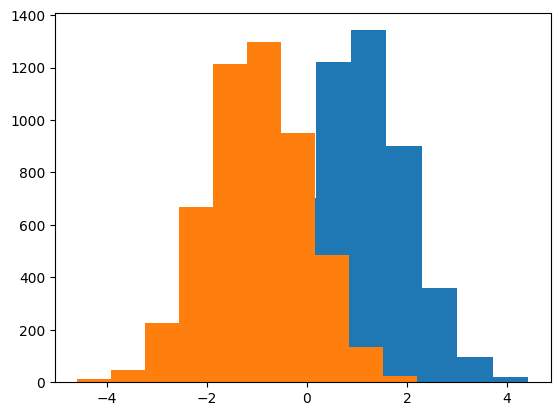

In [3]:
# scores for bads
bads = np.random.normal(0, 1, actual.sum()) + 1
# scores for goods
goods = np.random.normal(0, 1, len(actual) - actual.sum()) - 1
plt.hist(bads)
plt.hist(goods)

In the aforementioned code, we sampled bads scores and goods scores from two different standard normal distributions but we shifted them to create a separation between the two. We shift the bads scores (represented by the blue color in the image) by 1 towards the right and vice-versa by 1 towards the left. This ensures the following:

    1.  The bads scores are higher than the goods scores for a substantially high (as per the visual) cases
    2.  The bads scores have proportionately higher number of positive scores and the goods scores have proportionately higher number of negative scores

We can of course maximize this separation by increasing the ‘shift’ parameter and assign it values higher than 1. However, in this story, we won’t do that. We will explore that in the subsequent related stories. Now, let’s look at the probabilities generated by these scores.

(array([ 562., 1103.,  930.,  804.,  593.,  428.,  315.,  203.,   92.,
          29.]),
 array([0.01004327, 0.09914669, 0.1882501 , 0.27735352, 0.36645694,
        0.45556036, 0.54466378, 0.63376719, 0.72287061, 0.81197403,
        0.90107745]),
 <BarContainer object of 10 artists>)

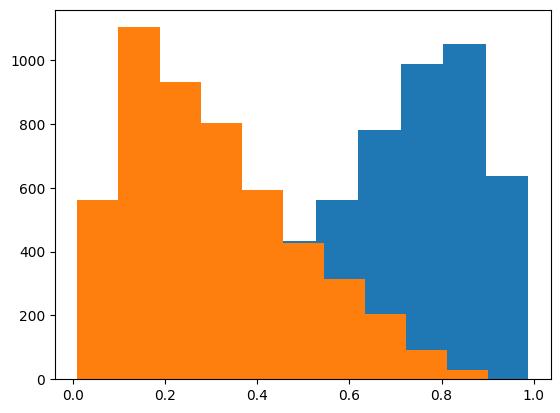

In [4]:
# prob for bads
bads_prob = list((map(lambda x: 1/(1 + math.exp(-x)), bads)))

# prob for goods
goods_prob = list((map(lambda x: 1/(1 + math.exp(-x)), goods)))

plt.hist(bads_prob)
plt.hist(goods_prob)

As discussed earlier, when the ‘scores’ are pushed through the logistic function, we get the probabilities. It is evident that the bad probabilities (blue color) are higher (and skewed towards 1), than the good probabilities (orange color) (and skewed towards 0).

The next step is to combine the actuals and predicted vectors into one single data frame for analysis. We assign bad probabilities where the data instance is actually bad and vice-versa

In [5]:
# create predicted array
bads = 0
goods = 0
predicted = np.zeros((10000))

for idx in range(0, len(actual)):
    if actual[idx] == 1:
        predicted[idx] = bads_prob[bads]
        bads += 1  
    else:
        predicted[idx] = goods_prob[goods]
        goods += 1  

actual_df = pd.DataFrame(actual, columns=['actual'])
predicted_df = pd.DataFrame(predicted, columns=['predicted'])
predicted_df = pd.concat([actual_df, predicted_df], axis = 1)
predicted_df = predicted_df.sort_values(['predicted'], ascending = False).reset_index()
predicted_df = predicted_df.drop(columns = 'predicted')

The next step is to create bins. This is because the curves that we want to generate are discrete in nature. For each bin, we calculate our desired metrics cumulatively. In other words, we generate cumulative distribution functions for the discrete random variables — goods and bads.

The number of bins is arbitrary (we assign n_bins = 50).
Note the use of floor function. This is because the length of the data frame may not divide equally into 50 bins. Thus, we take the floor of it and modify our code such that the last bin (50th bin) would contain the extra observations (which will be < 50).

In [6]:
n_bins = 50
bin_size = math.floor(len(predicted_df) / n_bins)

curve_metrics = []

In [7]:
print("number of bads:", bads)
print("number of goods:", goods)
print("number of total data points:", len(actual))
print("bin size:", len(predicted_df) / n_bins)

number of bads: 4941
number of goods: 5059
number of total data points: 10000
bin size: 200.0


Next comes the main code snippet where we make the actual calculations of the underlying metrics

In [8]:
for k in range(1, n_bins + 1):
    if k < n_bins:
        TP = predicted_df.loc[ : k*bin_size-1, "actual"].sum()
        FP = k*bin_size - TP
        FN = predicted_df.loc[(k*bin_size) : , "actual"].sum()
        TN = len(actual) - k*bin_size - FN

        cum_bads = predicted_df.loc[ : k*bin_size-1, "actual"].sum()
        cum_goods = k*bin_size - cum_bads
    else:
        TP = predicted_df.loc[ : , "actual"].sum()
        FP = len(actual) - TP
        FN = 0
        TN = 0

        cum_bads = bads
        cum_goods = goods

    curve_metrics.append([k, TP, FP, TN, FN, cum_bads, cum_goods])

In [9]:
curve_metrics

[[1,
  np.int64(200),
  np.int64(0),
  np.int64(5059),
  np.int64(4741),
  np.int64(200),
  np.int64(0)],
 [2,
  np.int64(400),
  np.int64(0),
  np.int64(5059),
  np.int64(4541),
  np.int64(400),
  np.int64(0)],
 [3,
  np.int64(599),
  np.int64(1),
  np.int64(5058),
  np.int64(4342),
  np.int64(599),
  np.int64(1)],
 [4,
  np.int64(795),
  np.int64(5),
  np.int64(5054),
  np.int64(4146),
  np.int64(795),
  np.int64(5)],
 [5,
  np.int64(991),
  np.int64(9),
  np.int64(5050),
  np.int64(3950),
  np.int64(991),
  np.int64(9)],
 [6,
  np.int64(1190),
  np.int64(10),
  np.int64(5049),
  np.int64(3751),
  np.int64(1190),
  np.int64(10)],
 [7,
  np.int64(1382),
  np.int64(18),
  np.int64(5041),
  np.int64(3559),
  np.int64(1382),
  np.int64(18)],
 [8,
  np.int64(1572),
  np.int64(28),
  np.int64(5031),
  np.int64(3369),
  np.int64(1572),
  np.int64(28)],
 [9,
  np.int64(1759),
  np.int64(41),
  np.int64(5018),
  np.int64(3182),
  np.int64(1759),
  np.int64(41)],
 [10,
  np.int64(1943),
  np.i

In [10]:
curve_metrics_df = pd.DataFrame(curve_metrics, columns=["cut_off_index", "TP", "FP", "TN", "FN", "cum_bads", "cum_goods"])
curve_metrics_df["cum%bads"] = curve_metrics_df["cum_bads"] / (actual.sum())
curve_metrics_df["cum%goods"] = curve_metrics_df["cum_goods"] / (len(actual) - actual.sum())

curve_metrics_df["precision"] = curve_metrics_df["TP"] / (curve_metrics_df["TP"] + curve_metrics_df["FP"])
curve_metrics_df["recall"] = curve_metrics_df["TP"] / (curve_metrics_df["TP"] + curve_metrics_df["FN"])
curve_metrics_df["sensitivity"] = curve_metrics_df["TP"] / (curve_metrics_df["TP"] + curve_metrics_df["FN"])
# specificity is the recall on the negative class
curve_metrics_df["specificity"] = curve_metrics_df["TN"] / (curve_metrics_df["TN"] + curve_metrics_df["FP"]) 

The ROC curve is a curve between cumulative bads (Y-axis) and cumulative goods (X-axis)
The ROC curve is a curve between sensitivity (which is also cumulative bads or recall : Y-axis) and 1-specificity (X-axis)
The Precision Recall curve is a curve between Precision (Y-axis) and Recall (which is also sensitivity or cumulative bads: X-axis)
That’s it. We have everything needed to plot our curves now.

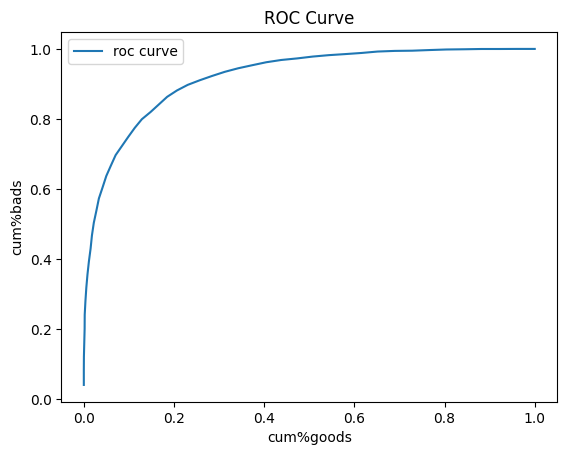

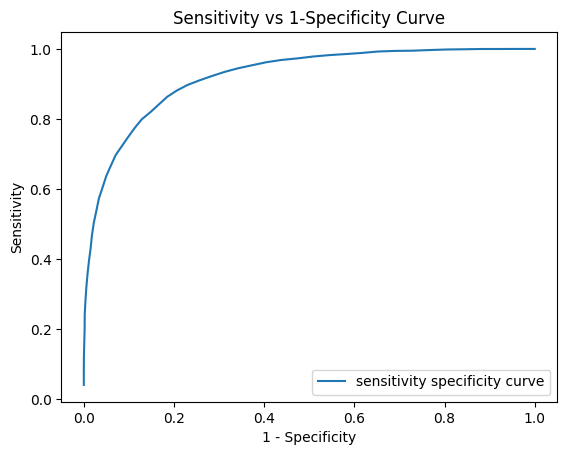

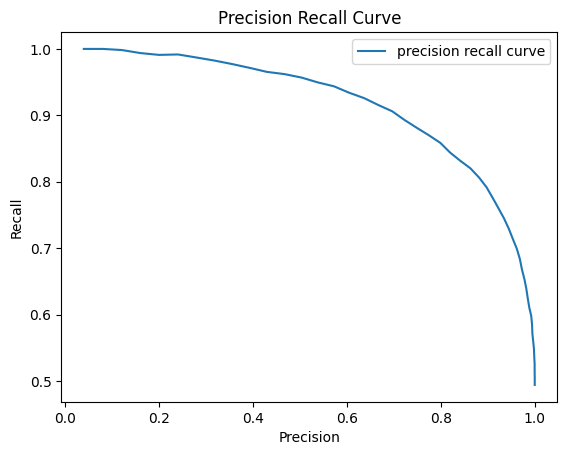

In [11]:
plt.plot(curve_metrics_df["cum%goods"], curve_metrics_df["cum%bads"], label ="roc curve")
plt.xlabel("cum%goods")
plt.ylabel("cum%bads")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.plot(1 - curve_metrics_df["specificity"], curve_metrics_df["sensitivity"], label ="sensitivity specificity curve")
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs 1-Specificity Curve")
plt.legend()
plt.show()

plt.plot(curve_metrics_df["recall"], curve_metrics_df["precision"], label ="precision recall curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision Recall Curve")
plt.legend()
plt.show()